<a href="https://colab.research.google.com/github/DAJananiTK/IT-Service-Desk-Analytics-using-Python/blob/main/Python_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stage 1**

**IT Service Desk Ticket Analysis Using Python**

**Business** **Problem**

Organizations rely on IT service desks to resolve technical issues quickly and maintain uninterrupted business operations. However, managing a large volume of support tickets across different departments, priorities, and services can be challenging. Delays in response and resolution, SLA breaches, ticket escalations, and uneven workload distribution among support agents can negatively impact employee productivity and service quality.This project aims to analyze IT service desk ticket data to identify operational bottlenecks, evaluate support performance, and uncover trends in ticket management. The insights generated will help improve response efficiency, optimize resource allocation, reduce SLA violations, and support data-driven decision-making for enhancing overall IT service management.

**Dataset** **Information**

Source : Mindweave Technologies. Help Desk Tickets (Synthetic) dataset, available through Hugging Face Datasets.

Location : Global (Synthetic Dataset – Not Associated with a Specific Country or Region)

Year/Timeline : Data collected during the period 2024 to 2025

Domain: Information Technology (IT)

**Objectives**



1.   To analyze the overall distribution and trends of IT service desk support tickets.
2.   To evaluate ticket resolution performance across different priority levels and ticket statuses.

1.   To identify the most common ticket categories, affected services, and support channels.

1.   To assess the performance and workload distribution of IT support agents and teams.
2. To examine the impact of SLA breaches, escalations, and outages on IT service desk operations.




1.   To provide recommendations for improving IT service desk performance based on the analysis findings.







**Expected Outcome**



1. Gain insights into ticket distribution and service trends.
2.  Evaluate ticket response and resolution performance.

1.   Identify common ticket categories, services, and support channels.
2.  Assess IT support agent performance and workload.

1.   Analyze the impact of SLA breaches, escalations, and outages.
2.  Generate actionable insights to improve IT service management.







 **Import libraries**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



**Load the Dataset from github**

In [2]:
import pandas as pd

tickets = pd.read_csv("https://raw.githubusercontent.com/DAJananiTK/IT-Service-Desk-Analytics-using-Python/main/dataset/tickets.csv")

agents = pd.read_csv("https://raw.githubusercontent.com/DAJananiTK/IT-Service-Desk-Analytics-using-Python/main/dataset/agents.csv")

categories = pd.read_csv("https://raw.githubusercontent.com/DAJananiTK/IT-Service-Desk-Analytics-using-Python/main/dataset/categories.csv")

comments = pd.read_csv("https://raw.githubusercontent.com/DAJananiTK/IT-Service-Desk-Analytics-using-Python/main/dataset/comments.csv")

sla_breaches = pd.read_csv("https://raw.githubusercontent.com/DAJananiTK/IT-Service-Desk-Analytics-using-Python/main/dataset/sla_breaches.csv")

**Initial EDA**

In [3]:
# head-view the first 5 rows
print("Tickets")
display(tickets.head())

print("Agents")
display(agents.head())

print("Categories")
display(categories.head())

print("Comments")
display(comments.head())

print("SLA Breaches")
display(sla_breaches.head())

Tickets


,ticket_id,created_at,first_response_at,resolved_at,priority,status,channel,category_id,assigned_agent_id,requester_department,affected_service,summary,description,escalated,outage_related
0,1,2024-01-01 00:25:58,2024-01-01 02:44:28.165882055,2024-01-01 07:11:36.270497762,P2,resolved,email,5,8,Finance,business-apps,New Zebra printer not visible to shipping stat...,New Zebra printer not visible to shipping stat...,False,False
1,2,2024-01-01 03:18:47,2024-01-01 10:41:36.758167460,2024-01-01 16:06:15.515350209,P3,resolved,email,8,5,Warehouse,voice,Sales laptop webcam missing from device manager.,Sales laptop webcam missing from device manage...,False,False
2,3,2024-01-01 05:00:04,2024-01-01 07:14:00.495197408,2024-01-03 05:17:17.430912834,P4,resolved,chat,4,2,IT,saas,Outlook keeps prompting for password on Mac.,Outlook keeps prompting for password on Mac. R...,False,False
3,4,2024-01-01 06:54:27,2024-01-01 13:53:34.348455884,2024-01-02 01:21:58.211483652,P3,resolved,portal,7,10,IT,security,VPN disconnects every 15 minutes on hotel Wi-Fi.,VPN disconnects every 15 minutes on hotel Wi-F...,False,False
4,5,2024-01-01 07:51:13,2024-01-01 09:57:48.722425448,2024-01-02 00:47:37.929284761,P3,resolved,chat,3,2,Finance,network,Spam burst hit shared support inbox this morning.,Spam burst hit shared support inbox this morni...,False,False


Agents


,id,name,team
0,1,Maya Patel,tier-1
1,2,Jordan Kim,tier-1
2,3,Avery Thompson,tier-1
3,4,Lucas Nguyen,tier-2
4,5,Sofia Ramirez,tier-2


Categories


,id,name,service
0,1,Access Management,identity
1,2,Laptop / Endpoint,endpoint
2,3,Network & VPN,network
3,4,Email & Collaboration,saas
4,5,ERP / WMS,business-apps


Comments


,comment_id,ticket_id,agent_id,created_at,visibility,team,body
0,1,1,8,2024-01-01 07:51:48.512407,public,business-apps,Issue now limited to users on macOS Sonoma.
1,2,1,8,2024-01-01 15:37:09.392051,public,business-apps,Issue now limited to users on macOS Sonoma.
2,3,1,8,2024-01-02 01:44:23.067300,internal,business-apps,Confirmed issue reproducible on spare device.
3,4,1,8,2024-01-02 19:26:32.801904,public,business-apps,MFA re-registration completed successfully.
4,5,2,5,2024-01-01 14:31:12.901622,public,tier-2,Monitor issue persisted after cable swap.


SLA Breaches


,breach_id,ticket_id,breach_type,sla_target_hours,actual_hours,breach_minutes
0,1,11,resolution,24,28.51,270
1,2,13,resolution,72,75.94,236
2,3,15,resolution,72,74.87,172
3,4,20,resolution,72,76.87,292
4,5,21,resolution,72,74.25,134


In [4]:
# info- checks the dataset information
tickets.info()

agents.info()

categories.info()

comments.info()

sla_breaches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ticket_id             1000 non-null   int64 
 1   created_at            1000 non-null   object
 2   first_response_at     1000 non-null   object
 3   resolved_at           899 non-null    object
 4   priority              1000 non-null   object
 5   status                1000 non-null   object
 6   channel               1000 non-null   object
 7   category_id           1000 non-null   int64 
 8   assigned_agent_id     1000 non-null   int64 
 9   requester_department  1000 non-null   object
 10  affected_service      1000 non-null   object
 11  summary               1000 non-null   object
 12  description           1000 non-null   object
 13  escalated             1000 non-null   bool  
 14  outage_related        1000 non-null   bool  
dtypes: bool(2), int64(3), object(10)
memory

In [5]:
# describe- view the statistical summary of tables having numeric columns
tickets.describe()






,ticket_id,category_id,assigned_agent_id
count,1000.000000,1000.000000,1000.00000
mean,500.500000,4.454000,5.53700
std,288.819436,2.308942,2.88287
min,1.000000,1.000000,1.00000
25%,250.750000,2.000000,3.00000
50%,500.500000,4.000000,6.00000
75%,750.250000,6.250000,8.00000
max,1000.000000,8.000000,10.00000


In [6]:
# shape- checks the shape
print("Tickets:", tickets.shape)
print("Agents:", agents.shape)
print("Categories:", categories.shape)
print("Comments:", comments.shape)
print("SLA Breaches:", sla_breaches.shape)

Tickets: (1000, 15)
Agents: (10, 3)
Categories: (8, 3)
Comments: (2000, 7)
SLA Breaches: (1249, 6)


In [7]:
# isnull()- checks the missing values
print(tickets.isnull().sum())

print(agents.isnull().sum())

print(categories.isnull().sum())

print(comments.isnull().sum())

print(sla_breaches.isnull().sum())

ticket_id                 0
created_at                0
first_response_at         0
resolved_at             101
priority                  0
status                    0
channel                   0
category_id               0
assigned_agent_id         0
requester_department      0
affected_service          0
summary                   0
description               0
escalated                 0
outage_related            0
dtype: int64
id      0
name    0
team    0
dtype: int64
id         0
name       0
service    0
dtype: int64
comment_id    0
ticket_id     0
agent_id      0
created_at    0
visibility    0
team          0
body          0
dtype: int64
breach_id           0
ticket_id           0
breach_type         0
sla_target_hours    0
actual_hours        0
breach_minutes      0
dtype: int64


In [8]:
# duplicated()-checks the duplicate records
print("Tickets:", tickets.duplicated().sum())

print("Agents:", agents.duplicated().sum())

print("Categories:", categories.duplicated().sum())

print("Comments:", comments.duplicated().sum())

print("SLA Breaches:", sla_breaches.duplicated().sum())

Tickets: 0
Agents: 0
Categories: 0
Comments: 0
SLA Breaches: 0


**Stage 2**

**Data Cleaning,Data Transformation and Feature Engineering**

In [9]:
# Data cleaning
# check the duplicates

print("Tickets:", tickets.duplicated().sum())
print("Agents:", agents.duplicated().sum())
print("Categories:", categories.duplicated().sum())
print("Comments:", comments.duplicated().sum())
print("SLA Breaches:", sla_breaches.duplicated().sum())

Tickets: 0
Agents: 0
Categories: 0
Comments: 0
SLA Breaches: 0


In [10]:
#find the missing value

print("Tickets")
print(tickets.isnull().sum())

print("\nAgents")
print(agents.isnull().sum())

print("\nCategories")
print(categories.isnull().sum())

print("\nComments")
print(comments.isnull().sum())

print("\nSLA Breaches")
print(sla_breaches.isnull().sum())

Tickets
ticket_id                 0
created_at                0
first_response_at         0
resolved_at             101
priority                  0
status                    0
channel                   0
category_id               0
assigned_agent_id         0
requester_department      0
affected_service          0
summary                   0
description               0
escalated                 0
outage_related            0
dtype: int64

Agents
id      0
name    0
team    0
dtype: int64

Categories
id         0
name       0
service    0
dtype: int64

Comments
comment_id    0
ticket_id     0
agent_id      0
created_at    0
visibility    0
team          0
body          0
dtype: int64

SLA Breaches
breach_id           0
ticket_id           0
breach_type         0
sla_target_hours    0
actual_hours        0
breach_minutes      0
dtype: int64


In [11]:
# Rename the columns
tickets.columns


Index(['ticket_id', 'created_at', 'first_response_at', 'resolved_at',
       'priority', 'status', 'channel', 'category_id', 'assigned_agent_id',
       'requester_department', 'affected_service', 'summary', 'description',
       'escalated', 'outage_related'],
      dtype='object')

In [12]:
tickets.shape

(1000, 15)

In [13]:
# Drop the unwanted columns
tickets.drop(columns=['summary', 'description'], inplace=True)

In [14]:
# recheck the dropped column
tickets.columns

Index(['ticket_id', 'created_at', 'first_response_at', 'resolved_at',
       'priority', 'status', 'channel', 'category_id', 'assigned_agent_id',
       'requester_department', 'affected_service', 'escalated',
       'outage_related'],
      dtype='object')

In [15]:
tickets.shape

(1000, 13)

In [16]:
# convert the data types

# Convert datetime columns
tickets['created_at'] = pd.to_datetime(tickets['created_at'])
tickets['resolved_at'] = pd.to_datetime(tickets['resolved_at'])

# Convert categorical columns
category_columns = [
    'priority',
    'status',
    'channel',
    'requester_department',
    'affected_service'
]

for col in category_columns:
    tickets[col] = tickets[col].astype('category')



In [17]:
# check the converted datatypes
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ticket_id             1000 non-null   int64         
 1   created_at            1000 non-null   datetime64[ns]
 2   first_response_at     1000 non-null   object        
 3   resolved_at           899 non-null    datetime64[ns]
 4   priority              1000 non-null   category      
 5   status                1000 non-null   category      
 6   channel               1000 non-null   category      
 7   category_id           1000 non-null   int64         
 8   assigned_agent_id     1000 non-null   int64         
 9   requester_department  1000 non-null   category      
 10  affected_service      1000 non-null   category      
 11  escalated             1000 non-null   bool          
 12  outage_related        1000 non-null   bool          
dtypes: bool(2), categor

**Data Transformation**

In [18]:
from functools import reduce

dfs = [
    (categories, {'left_on': 'category_id', 'right_on': 'id'}),
    (agents, {'left_on': 'assigned_agent_id', 'right_on': 'id',
              'suffixes': ('_category', '_agent')}),
    (sla_breaches, {'on': 'ticket_id'})
]

final_df = reduce(
    lambda left, right: pd.merge(left, right[0], how='left', **right[1]),
    dfs,
    tickets
)

In [19]:
final_df.head()

,ticket_id,created_at,first_response_at,resolved_at,priority,status,channel,category_id,assigned_agent_id,requester_department,...,name_category,service,id_agent,name_agent,team,breach_id,breach_type,sla_target_hours,actual_hours,breach_minutes
0,1,2024-01-01 00:25:58,2024-01-01 02:44:28.165882055,2024-01-01 07:11:36.270497762,P2,resolved,email,5,8,Finance,...,ERP / WMS,business-apps,8,Derrick Cole,business-apps,NaN,NaN,NaN,NaN,NaN
1,2,2024-01-01 03:18:47,2024-01-01 10:41:36.758167460,2024-01-01 16:06:15.515350209,P3,resolved,email,8,5,Warehouse,...,Telephony,voice,5,Sofia Ramirez,tier-2,NaN,NaN,NaN,NaN,NaN
2,3,2024-01-01 05:00:04,2024-01-01 07:14:00.495197408,2024-01-03 05:17:17.430912834,P4,resolved,chat,4,2,IT,...,Email & Collaboration,saas,2,Jordan Kim,tier-1,NaN,NaN,NaN,NaN,NaN
3,4,2024-01-01 06:54:27,2024-01-01 13:53:34.348455884,2024-01-02 01:21:58.211483652,P3,resolved,portal,7,10,IT,...,Security,security,10,Olivia Chen,collaboration,NaN,NaN,NaN,NaN,NaN
4,5,2024-01-01 07:51:13,2024-01-01 09:57:48.722425448,2024-01-02 00:47:37.929284761,P3,resolved,chat,3,2,Finance,...,Network & VPN,network,2,Jordan Kim,tier-1,NaN,NaN,NaN,NaN,NaN


**Feature Engineering**

In [20]:
# extract year
final_df['Year'] = final_df['created_at'].dt.year

In [21]:
#extract month
final_df['Month'] = final_df['created_at'].dt.month_name()

In [22]:
# extract day
final_df['Day'] = final_df['created_at'].dt.day_name()

In [23]:
#extract quarter
final_df['Quarter'] = final_df['created_at'].dt.quarter

In [24]:
# create resolution status
final_df['Resolution_Status'] = final_df['resolved_at'].apply(
    lambda x: 'Resolved' if pd.notnull(x) else 'Unresolved'
)

In [25]:
# sla status
final_df['SLA_Status'] = final_df['breach_id'].apply(
    lambda x: 'Breached' if pd.notnull(x) else 'Not Breached'
)

**Final EDA**

In [26]:
# head- first 5 rows
final_df.head()

,ticket_id,created_at,first_response_at,resolved_at,priority,status,channel,category_id,assigned_agent_id,requester_department,...,breach_type,sla_target_hours,actual_hours,breach_minutes,Year,Month,Day,Quarter,Resolution_Status,SLA_Status
0,1,2024-01-01 00:25:58,2024-01-01 02:44:28.165882055,2024-01-01 07:11:36.270497762,P2,resolved,email,5,8,Finance,...,NaN,NaN,NaN,NaN,2024,January,Monday,1,Resolved,Not Breached
1,2,2024-01-01 03:18:47,2024-01-01 10:41:36.758167460,2024-01-01 16:06:15.515350209,P3,resolved,email,8,5,Warehouse,...,NaN,NaN,NaN,NaN,2024,January,Monday,1,Resolved,Not Breached
2,3,2024-01-01 05:00:04,2024-01-01 07:14:00.495197408,2024-01-03 05:17:17.430912834,P4,resolved,chat,4,2,IT,...,NaN,NaN,NaN,NaN,2024,January,Monday,1,Resolved,Not Breached
3,4,2024-01-01 06:54:27,2024-01-01 13:53:34.348455884,2024-01-02 01:21:58.211483652,P3,resolved,portal,7,10,IT,...,NaN,NaN,NaN,NaN,2024,January,Monday,1,Resolved,Not Breached
4,5,2024-01-01 07:51:13,2024-01-01 09:57:48.722425448,2024-01-02 00:47:37.929284761,P3,resolved,chat,3,2,Finance,...,NaN,NaN,NaN,NaN,2024,January,Monday,1,Resolved,Not Breached


In [27]:
# shape-display the number of rows and columns
final_df.shape

(1000, 30)

In [28]:
# info-data information
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ticket_id             1000 non-null   int64         
 1   created_at            1000 non-null   datetime64[ns]
 2   first_response_at     1000 non-null   object        
 3   resolved_at           899 non-null    datetime64[ns]
 4   priority              1000 non-null   category      
 5   status                1000 non-null   category      
 6   channel               1000 non-null   category      
 7   category_id           1000 non-null   int64         
 8   assigned_agent_id     1000 non-null   int64         
 9   requester_department  1000 non-null   category      
 10  affected_service      1000 non-null   category      
 11  escalated             1000 non-null   bool          
 12  outage_related        1000 non-null   bool          
 13  id_category        

In [29]:
# describe-statistical summary
final_df.describe(include='all')


,ticket_id,created_at,first_response_at,resolved_at,priority,status,channel,category_id,assigned_agent_id,requester_department,...,breach_type,sla_target_hours,actual_hours,breach_minutes,Year,Month,Day,Quarter,Resolution_Status,SLA_Status
count,1000.000000,1000,1000,899,1000,1000,1000,1000.000000,1000.00000,1000,...,101,101.000000,101.000000,101.000000,1000.0,1000,1000,1000.0,1000,1000
unique,NaN,NaN,1000,NaN,4,4,4,NaN,NaN,6,...,1,NaN,NaN,NaN,NaN,3,7,NaN,2,2
top,NaN,NaN,2024-03-10 22:00:41.407006760,NaN,P3,resolved,email,NaN,NaN,HR,...,resolution,NaN,NaN,NaN,NaN,January,Thursday,NaN,Resolved,Not Breached
freq,NaN,NaN,1,NaN,474,794,371,NaN,NaN,181,...,101,NaN,NaN,NaN,NaN,447,159,NaN,899,899
mean,500.500000,2024-02-04 16:13:16.563000064,NaN,2024-02-05 12:19:47.493811456,NaN,NaN,NaN,4.454000,5.53700,NaN,...,NaN,37.900990,41.437129,211.663366,2024.0,NaN,NaN,1.0,NaN,NaN
min,1.000000,2024-01-01 00:25:58,NaN,2024-01-01 07:11:36.270497762,NaN,NaN,NaN,1.000000,1.00000,NaN,...,NaN,4.000000,6.630000,64.000000,2024.0,NaN,NaN,1.0,NaN,NaN
25%,250.750000,2024-01-17 21:25:46.500000,NaN,2024-01-18 16:46:54.136928512,NaN,NaN,NaN,2.000000,3.00000,NaN,...,NaN,24.000000,25.770000,134.000000,2024.0,NaN,NaN,1.0,NaN,NaN
50%,500.500000,2024-02-04 17:11:46.500000,NaN,2024-02-06 04:11:52.253639680,NaN,NaN,NaN,4.000000,6.00000,NaN,...,NaN,24.000000,28.610000,216.000000,2024.0,NaN,NaN,1.0,NaN,NaN
75%,750.250000,2024-02-22 16:07:08.750000128,NaN,2024-02-22 22:45:16.859325952,NaN,NaN,NaN,6.250000,8.00000,NaN,...,NaN,72.000000,74.250000,286.000000,2024.0,NaN,NaN,1.0,NaN,NaN
max,1000.000000,2024-03-10 02:49:24,NaN,2024-03-12 13:08:12.966429143,NaN,NaN,NaN,8.000000,10.00000,NaN,...,NaN,72.000000,77.880000,359.000000,2024.0,NaN,NaN,1.0,NaN,NaN


In [30]:
# dtype-checks the datatypes
final_df.dtypes

,0
ticket_id,int64
created_at,datetime64[ns]
first_response_at,object
resolved_at,datetime64[ns]
priority,category
status,category
channel,category
category_id,int64
assigned_agent_id,int64
requester_department,category


**Stage 3**


**Statistical analysis & Visualizations**

In [31]:
# Measure of Central Tendency for Actual  Hours

mean_value = final_df['actual_hours'].mean()
median_value = final_df['actual_hours'].median()
mode_value = final_df['actual_hours'].mode()[0]

print("Measure of Central Tendency")
print("---------------------------")
print("Mean   :", round(mean_value, 2))
print("Median :", round(median_value, 2))
print("Mode   :", round(mode_value, 2))



Measure of Central Tendency
---------------------------
Mean   : 41.44
Median : 28.61
Mode   : 25.42


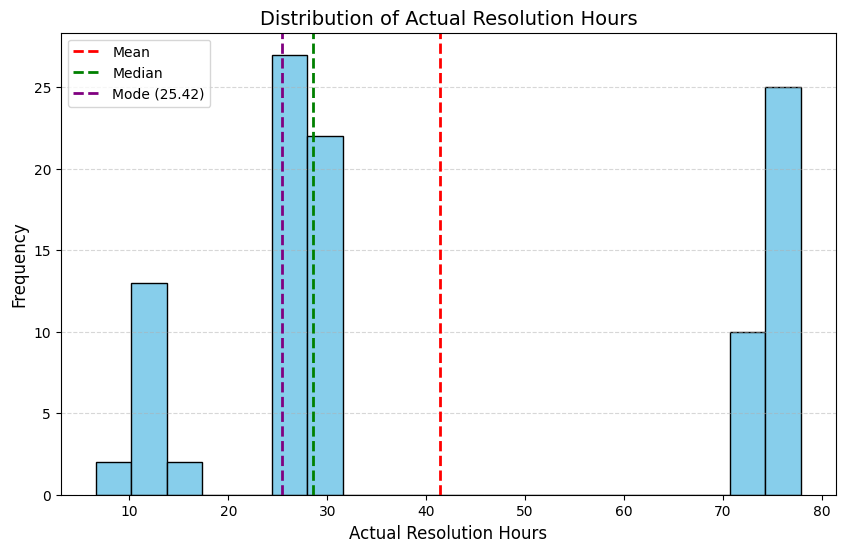

In [32]:
# Histogram for Actual  Hours
mode_value = final_df['actual_hours'].mode()[0]

plt.figure(figsize=(10,6))

plt.hist(final_df['actual_hours'].dropna(),
         bins=20,
         color='skyblue',
         edgecolor='black')

# Mean
plt.axvline(final_df['actual_hours'].mean(),
            color='red',
            linestyle='dashed',
            linewidth=2,
            label='Mean')

# Median
plt.axvline(final_df['actual_hours'].median(),
            color='green',
            linestyle='dashed',
            linewidth=2,
            label='Median')

# Mode
plt.axvline(mode_value,
            color='purple',
            linestyle='dashed',
            linewidth=2,
            label=f'Mode ({mode_value:.2f})')

plt.title('Distribution of Actual Resolution Hours', fontsize=14)
plt.xlabel('Actual Resolution Hours', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

**Interpretation**

1.  Most tickets are resolved within two prominent time ranges—approximately 25–30 hours and 72–78 hours—indicating two major groups of ticket resolution times.
2.   The mean is higher than the median and mode, indicating that tickets with longer resolution times increase the overall average resolution time.

1.   The distribution shows noticeable variation in ticket resolution hours, suggesting that different groups of tickets follow different resolution timelines, likely due to differences in priority or SLA requirements.






In [33]:
# Measure of Central Tendency for Breach Minutes

mean_value = final_df['breach_minutes'].mean()
median_value = final_df['breach_minutes'].median()
mode_value = final_df['breach_minutes'].mode()[0]

print("Measure of Central Tendency")
print("---------------------------")
print("Mean   :", round(mean_value, 2))
print("Median :", round(median_value, 2))
print("Mode   :", round(mode_value, 2))

Measure of Central Tendency
---------------------------
Mean   : 211.66
Median : 216.0
Mode   : 270.0


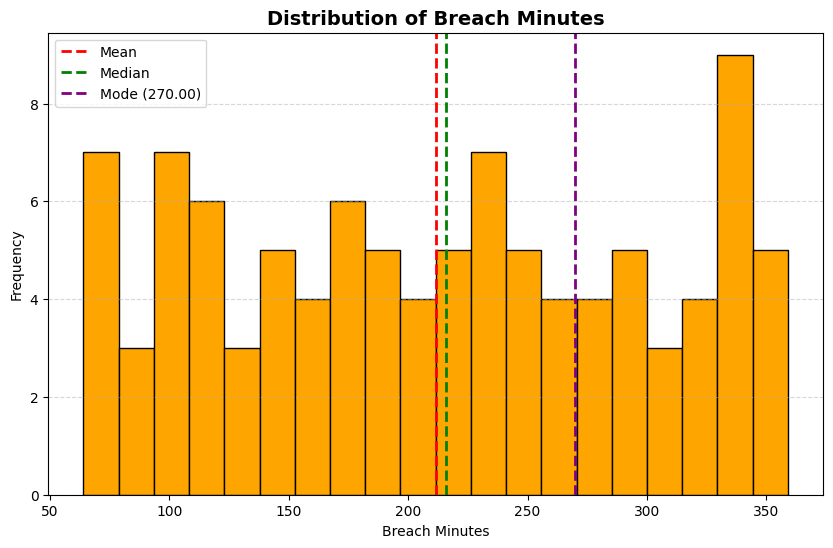

In [34]:
# Histogram for Breach Minutes

plt.figure(figsize=(10,6))

mode_value = final_df['breach_minutes'].mode()[0]

plt.hist(final_df['breach_minutes'].dropna(),
         bins=20,
         color='orange',
         edgecolor='black')

# Mean
plt.axvline(final_df['breach_minutes'].mean(),
            color='red',
            linestyle='dashed',
            linewidth=2,
            label='Mean')

# Median
plt.axvline(final_df['breach_minutes'].median(),
            color='green',
            linestyle='dashed',
            linewidth=2,
            label='Median')

# Mode
plt.axvline(mode_value,
            color='purple',
            linestyle='dashed',
            linewidth=2,
            label=f'Mode ({mode_value:.2f})')

plt.title('Distribution of Breach Minutes', fontsize=14, fontweight='bold')
plt.xlabel('Breach Minutes')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

**Interpretation**

1. Breach minutes are distributed across a wide range (approximately 60–360 minutes), indicating that SLA breach durations vary significantly among tickets.
2.   The mean and median are close to each other (around 215–220 minutes), suggesting that the average breach duration is representative of most tickets.

1.  The mode is 270 minutes, indicating that a breach duration of 270 minutes occurs more frequently than any other individual value in the dataset.




In [35]:
# Variance and Standard Deviation for Actual Hours

variance = final_df['actual_hours'].var()
std_dev = final_df['actual_hours'].std()

print("Measure of Dispersion")
print("---------------------")
print("Variance            :", round(variance, 2))
print("Standard Deviation  :", round(std_dev, 2))

Measure of Dispersion
---------------------
Variance            : 650.34
Standard Deviation  : 25.5


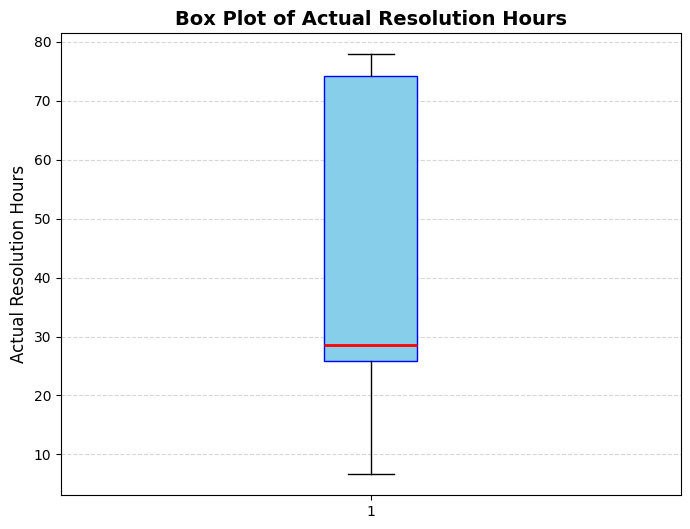

In [36]:
# Box Plot for Actual Hours

plt.figure(figsize=(8,6))

plt.boxplot(
    final_df['actual_hours'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='blue'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='orange',
                    markersize=6, markeredgecolor='black')
)

plt.title('Box Plot of Actual Resolution Hours', fontsize=14, fontweight='bold')
plt.ylabel('Actual Resolution Hours', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Interpretation**


1. The median actual resolution time is approximately 28 hours, indicating that half of the tickets were resolved within about 28 hours.
2. The wide box and long whiskers indicate a large spread in actual resolution hours, supporting the high variance (650.34) and standard deviation (25.50 hours).

1.  No significant outliers are observed, suggesting that the variation in resolution times is distributed across the dataset rather than caused by a few extreme values.



In [37]:
# Variance and Standard Deviation for Breach Minutes

variance = final_df['breach_minutes'].var()
std_dev = final_df['breach_minutes'].std()

print("Measure of Dispersion")
print("---------------------")
print("Variance            :", round(variance, 2))
print("Standard Deviation  :", round(std_dev, 2))

Measure of Dispersion
---------------------
Variance            : 7916.47
Standard Deviation  : 88.97


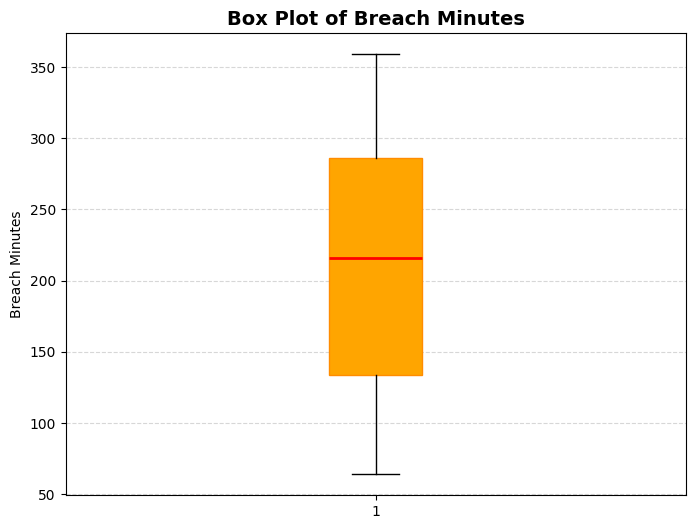

In [38]:
# Box Plot for Breach Minutes

plt.figure(figsize=(8,6))

plt.boxplot(
    final_df['breach_minutes'].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='orange', color='darkorange'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='yellow',
                    markeredgecolor='black', markersize=6)
)

plt.title('Box Plot of Breach Minutes', fontsize=14, fontweight='bold')
plt.ylabel('Breach Minutes')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Interpretation**

1.  The median breach time is approximately 215 minutes, indicating that 50% of the SLA breaches occurred within about 215 minutes.
2.  The wide box and long whiskers indicate a large spread in breach minutes, supporting the high variance (7916.47) and standard deviation (88.97 minutes).

1.   No significant outliers are observed, suggesting that the variation in breach minutes is distributed across the dataset rather than being caused by a few extreme breach durations.




In [39]:
# skewness and kurtosis values for Actual Hours and Breach Minutes

shape_summary = pd.DataFrame({
    'Measure': ['Skewness', 'Kurtosis'],
    'Actual Resolution Hours': [
        round(final_df['actual_hours'].skew(), 2),
        round(final_df['actual_hours'].kurt(), 2)
    ],
    'Breach Minutes': [
        round(final_df['breach_minutes'].skew(), 2),
        round(final_df['breach_minutes'].kurt(), 2)
    ]
})

shape_summary

,Measure,Actual Resolution Hours,Breach Minutes
0,Skewness,0.48,0.0
1,Kurtosis,-1.53,-1.2


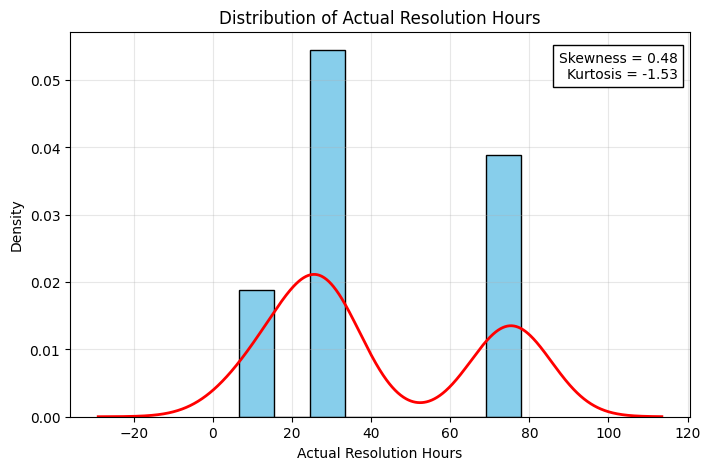

In [40]:
# Distribution with Skewness and Kurtosis for Actual hours

skew = final_df['actual_hours'].skew()
kurt = final_df['actual_hours'].kurt()

plt.figure(figsize=(8,5))

# Histogram
final_df['actual_hours'].plot(
    kind='hist',
    bins=8,
    density=True,
    color='skyblue',
    edgecolor='black'
)

# Density curve
final_df['actual_hours'].plot(
    kind='kde',
    color='red',
    linewidth=2
)

# Display values
plt.text(
    0.98, 0.95,
    f"Skewness = {skew:.2f}\nKurtosis = {kurt:.2f}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.title('Distribution of Actual Resolution Hours')
plt.xlabel('Actual Resolution Hours')
plt.ylabel('Density')
plt.grid(alpha=0.3)

plt.show()

**Interpretation**

1. The Actual Resolution Hours distribution is slightly positively skewed (Skewness = 0.48), indicating that a few tickets take longer to resolve than most others.
2.   The kurtosis value of -1.53 indicates a platykurtic distribution, meaning the data is flatter than a normal distribution with fewer extreme values.

1. The histogram and density curve show that most ticket resolution times are concentrated in two main ranges, indicating two common resolution patterns.





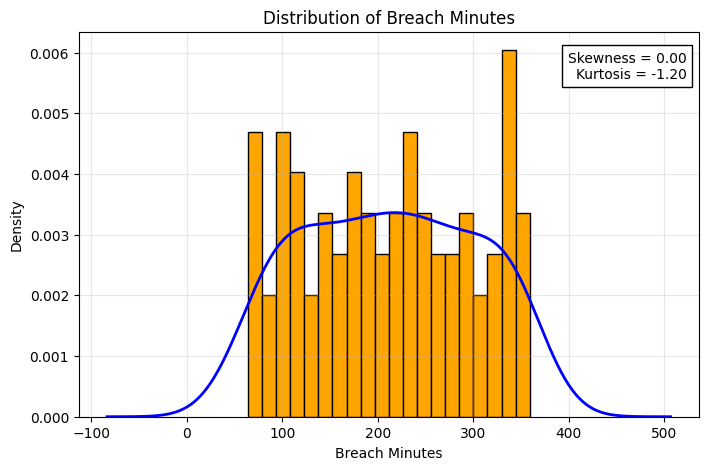

In [41]:
# Distribution with Skewness and Kurtosis for Breach Minutes
skew = final_df['breach_minutes'].skew()
kurt = final_df['breach_minutes'].kurt()

plt.figure(figsize=(8,5))

# Histogram
final_df['breach_minutes'].plot(
    kind='hist',
    bins=20,
    density=True,
    color='orange',
    edgecolor='black'
)

# Density Curve
final_df['breach_minutes'].plot(
    kind='kde',
    color='blue',
    linewidth=2
)

# Display Skewness and Kurtosis
plt.text(
    0.98, 0.95,
    f"Skewness = {skew:.2f}\nKurtosis = {kurt:.2f}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.title('Distribution of Breach Minutes')
plt.xlabel('Breach Minutes')
plt.ylabel('Density')
plt.grid(alpha=0.3)

plt.show()

**Interpretation**

1.  The Breach Minutes distribution is nearly symmetric (Skewness = 0.00), indicating that breach durations are evenly distributed around the center without a noticeable left or right skew.
2.  The kurtosis value of -1.20 indicates a platykurtic distribution, meaning the distribution is flatter than a normal distribution with fewer extreme values.

1. The histogram and density curve show that breach durations are spread across a broad range (approximately 60–360 minutes), indicating moderate variability without a strong concentration at a single value.





**Univariate Analysis**


It examines a single variable at a time to understand its distribution, frequency, and overall characteristics. In this project, the analysis focuses on individual features such as ticket priority, ticket category, affected service, support channel, resolution status, and monthly ticket trends. The following visualizations are used to summarize the distribution of each variable:


1.   **Line Chart**: Analyze the monthly trend of IT support tickets over the observed period.
2.  **Count Plot**: Analyze the distribution of tickets across different priority levels.



2.  **Pie Chart**: Identify the proportion of tickets in each ticket category.


1.   **Count Plot**: Analyze the distribution of tickets across different ticket statuses to evaluate the overall status of IT support tickets.





1.  **Horizontal Bar Chart**: Compare the frequency of tickets across affected services.














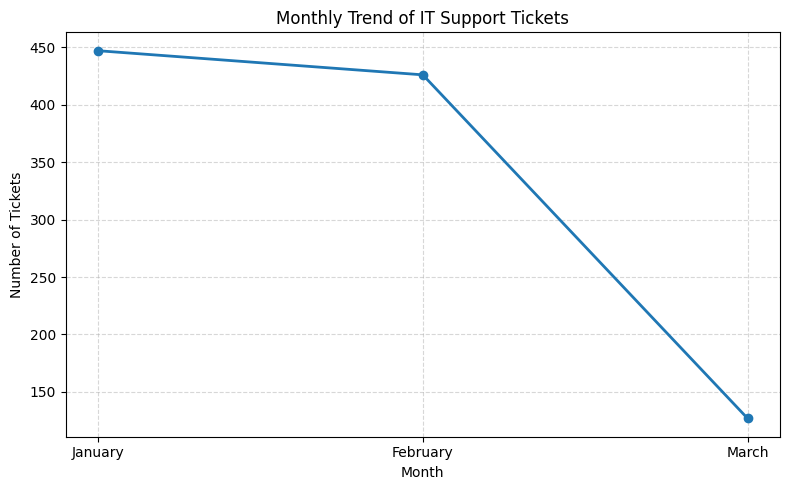

In [42]:
# Line Chart: Analyze the monthly trend in the number of IT support tickets

month_order = ['January', 'February', 'March']

monthly_tickets = (
    final_df['Month']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(8,5))

plt.plot(monthly_tickets.index,
         monthly_tickets.values,
         marker='o',
         linewidth=2)

plt.title('Monthly Trend of IT Support Tickets')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Interpretation**


1.  The line chart illustrates the monthly trend of IT support tickets from January to March, showing how the number of support requests changes over time.
2.  The highest number of tickets was recorded in January (447), followed by a slight decrease in February (426). Ticket volume then dropped significantly in March (127), indicating a substantial reduction in support requests during the observed period.

1.   **Column**: Month
2. **Business Story** : The monthly trend indicates that IT support demand was highest at the beginning of the year and declined over the following months. This information helps the organization anticipate periods of high support demand, optimize resource allocation, and plan staffing effectively to maintain efficient service delivery. Since the dataset contains records only from January to March, the analysis is limited to this time period.





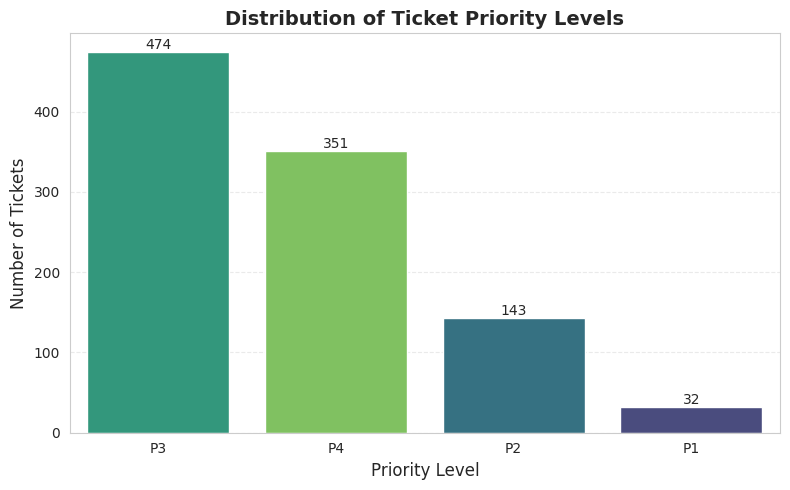

In [43]:
# Count Plot: Distribution of Ticket Priority Levels


sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=final_df,
    x='priority',
    hue='priority',
    order=final_df['priority'].value_counts().index,
    palette='viridis',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of Ticket Priority Levels", fontsize=14, fontweight='bold')
plt.xlabel("Priority Level", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretation**

1.   The chart shows the distribution of tickets across different priority levels.
2.   P3 has the highest number of tickets (474), followed by P4 (351), P2 (143), and P1 (32). Most tickets are medium priority, while critical tickets are few.




1.   **Column**: priority






2.   **Business Story** : he service desk primarily handles P3 and P4 tickets, indicating that routine operational issues make up most support requests. Since P1 and P2 tickets are fewer but more critical, they require rapid response and dedicated attention to minimize business impact. This insight helps the organization prioritize resources effectively while ensuring critical issues receive immediate support.





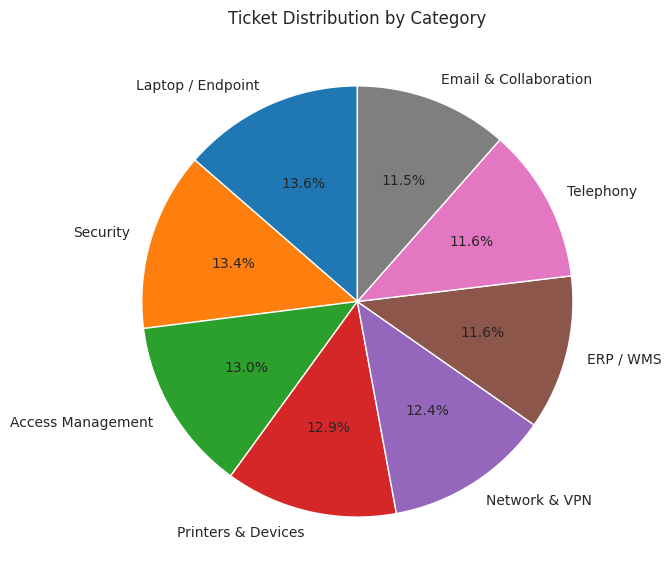

In [44]:
# pie chart- Distribution of ticket categories

category = final_df['name_category'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category,
    labels=category.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Ticket Distribution by Category')

plt.show()

**Interpretation**


1.   This pie chart illustrates the percentage distribution of support tickets across different ticket categories.
2.   Laptop / Endpoint (13.6%) and Security (13.4%) account for the highest share of support tickets.

1.  The remaining categories contribute between 11% and 13%, indicating a fairly balanced distribution of ticket types.
2. No single category dominates the overall ticket volume.

1.   **Column**: name_category
2.   **Business Story** : The service desk receives support requests across multiple IT categories, with Laptop / Endpoint generating the highest demand. The fairly even distribution across all categories indicates that users experience issues with a wide range of IT services rather than a single dominant problem area. This insight helps the organization prioritize support resources, training, and maintenance efforts across all critical IT services while giving additional attention to high-volume categories like Laptop / Endpoint and Security.






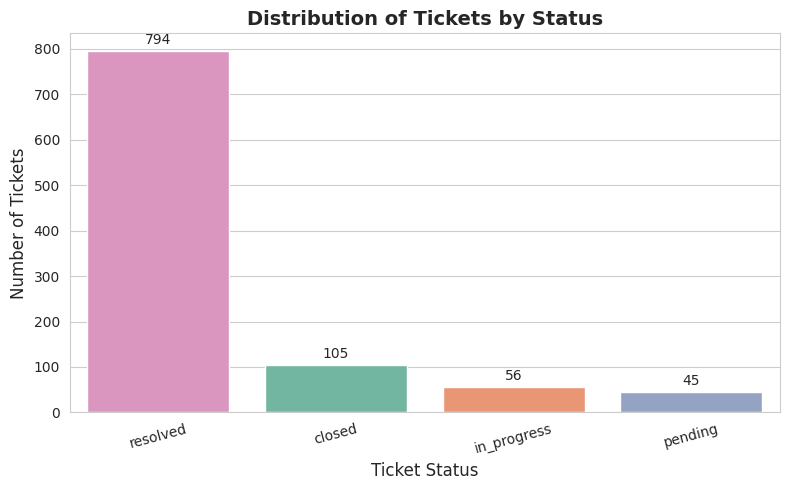

In [45]:
# Count Plot - Distribution of Tickets by Status


# Set figure size
plt.figure(figsize=(8, 5))

# Get ticket status order based on frequency
status_order = final_df['status'].value_counts().index

# Create the count plot
ax = sns.countplot(
    data=final_df,
    x='status',
    hue='status',
    order=status_order,
    palette='Set2',
    legend=False
)

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

# Add chart title and axis labels
plt.title('Distribution of Tickets by Status', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Status', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=15)

# Improve layout
plt.tight_layout()

# Display the chart
plt.show()

**Interpretation**


1.   The chart shows the distribution of support tickets across different ticket statuses.
2.   Resolved (794) has the highest number of tickets, followed by Closed (105), In Progress (56), and Pending (45).



1.  **column**: status
2.  **Business story** : The analysis indicates that most IT support tickets have been successfully resolved, reflecting an efficient ticket management process. The smaller number of In Progress and Pending tickets suggests that unresolved issues are limited, but they should continue to be monitored to ensure timely resolution and maintain high service quality.





affected_service
endpoint         136
security         134
identity         130
peripherals      129
network          124
business-apps    116
voice            116
saas             115
Name: count, dtype: int64


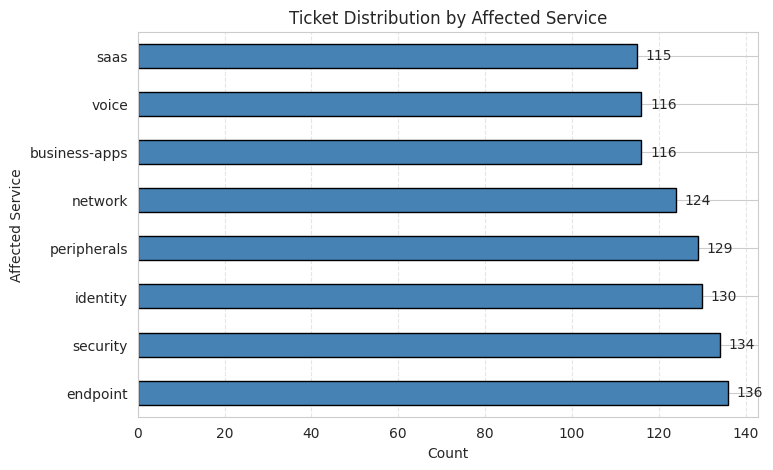

In [46]:
# Horizontal Bar Chart: Distribution of Tickets Across Affected IT Services

service = final_df['affected_service'].value_counts()

print(service)

plt.figure(figsize=(8,5))
service.plot(kind='barh', color='steelblue', edgecolor='black')

for i, v in enumerate(service):
    plt.text(v+2, i, str(v), va='center', fontsize=10)

plt.title('Ticket Distribution by Affected Service')
plt.xlabel('Count')
plt.ylabel('Affected Service')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

**Interpretation**


1.   The chart shows the distribution of support tickets across different affected IT services.
2.   Endpoint (136) is the most affected service, followed by Security (134) and Identity (130). SaaS (115) has the lowest number of tickets.



1.  **column**: affected_service
2.  **Business story** : The analysis shows that Endpoint services generate the highest number of support requests, making them a key area for IT support and maintenance. Since ticket volumes are relatively balanced across all affected services, the organization should ensure adequate technical expertise and resources are available for each service. This helps improve service reliability, reduce recurring issues, and maintain consistent IT support across the organization.





**Bivariate Analysis**

It examines the relationship between two variables to identify patterns, comparisons, and trends within the dataset. It helps understand how one variable influences or relates to another, enabling deeper insights into IT service desk operations and supporting data-driven decision-making.




1.  **Grouped Column Chart**: Support Channel vs Resolution Status





1.  **Bar Chart**: Ticket Priority vs Average Resolution Hours

1.   **Grouped Bar Chart**: Ticket Priority vs Resolution Status
2.   **Scatter Plot**: Actual Resolution Hours vs SLA Breach Minutes


2. **Horizontal Bar Chart**: Support Agent vs Number of Tickets















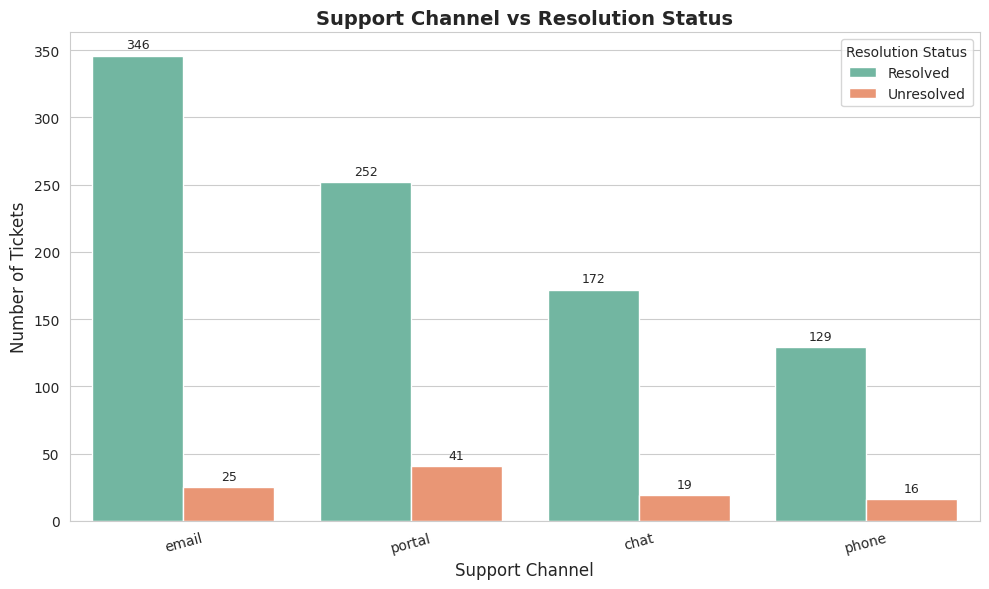

In [47]:
# Grouped Column Chart - Support Channel vs Resolution Status


# Set figure size
plt.figure(figsize=(10, 6))

# Define the order of support channels based on ticket count
channel_order = final_df['channel'].value_counts().index

# Create grouped column chart
ax = sns.countplot(
    data=final_df,
    x='channel',
    hue='Resolution_Status',
    order=channel_order,
    palette='Set2'
)

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

# Add chart title and axis labels
plt.title('Support Channel vs Resolution Status', fontsize=14, fontweight='bold')
plt.xlabel('Support Channel', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=15)

# Add legend
plt.legend(title='Resolution Status')

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

**Interpretation**


1.   The chart shows the distribution of resolved and unresolved support tickets across different support channels.
2.   Email (346) has the highest number of resolved tickets, followed by Portal (252), Chat (172), and Phone (129). Among unresolved tickets, Portal (41) has the highest count, while Phone (16) has the lowest.


1.   **Columns**: channel, Resolution_Status
2.  **Business Story**:The analysis indicates that Email is the most frequently used support channel and successfully resolves the highest number of tickets. Portal has the largest number of unresolved tickets, suggesting that this channel may require improvements in ticket handling or response efficiency. Monitoring unresolved tickets across support channels can help optimize support operations, improve response times, and enhance customer satisfaction.










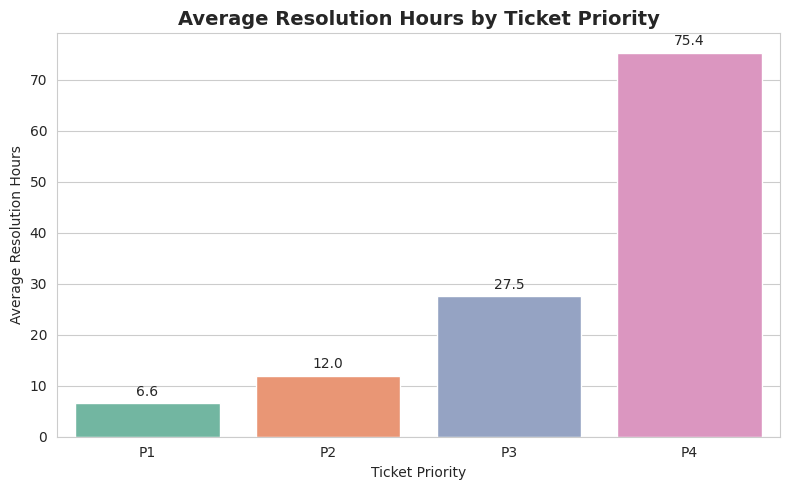

In [48]:
# Bar Chart: Ticket Priority vs Average Resolution Hours

priority_avg = (
    final_df.groupby('priority', observed=False)['actual_hours']
    .mean()
    .reset_index()
)

# Define priority order
priority_order = ['P1', 'P2', 'P3', 'P4']

# Create bar chart
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=priority_avg,
    x='priority',
    y='actual_hours',
    order=priority_order,
    hue='priority',
    palette='Set2',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

# Title and labels
plt.title('Average Resolution Hours by Ticket Priority',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Ticket Priority')
plt.ylabel('Average Resolution Hours')

plt.tight_layout()
plt.show()

**Interpretation**


1.   The bar chart compares the average resolution hours across different ticket priority levels (P1–P4).

2. The average resolution time increases from P1 (6.6 hours) to P4 (75.4 hours). High-priority tickets are resolved more quickly, while low-priority tickets take longer.




1.   **Features Used**: actual_hours and priority
2.  **Business story** : The results indicate that the IT support team prioritizes critical tickets for faster resolution while allocating more time to lower-priority issues. This reflects an effective priority-based ticket management process and supports better SLA performance.







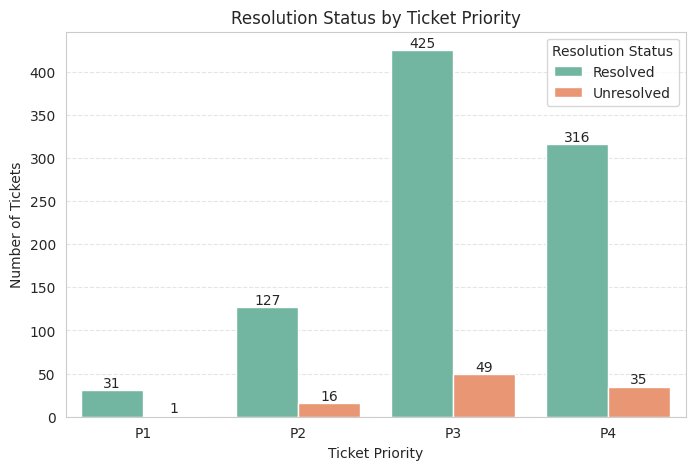

In [49]:
# Grouped Bar Chart: Ticket Priority vs Resolution Status

plt.figure(figsize=(8,5))

priority_order = ['P1', 'P2', 'P3', 'P4']

ax = sns.countplot(
    data=final_df,
    x='priority',
    hue='Resolution_Status',
    order=priority_order,
    palette='Set2'
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Resolution Status by Ticket Priority')
plt.xlabel('Ticket Priority')
plt.ylabel('Number of Tickets')

plt.legend(title='Resolution Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Interpretation**


1.   The grouped bar chart compares the number of resolved and unresolved tickets across different ticket priority levels (P1–P4).
2.   Across all priority levels, resolved tickets are significantly higher than unresolved tickets. P3 has the highest number of resolved tickets (425), while unresolved tickets remain comparatively low across all priorities.




1.   **Features Used**: priority and resolution_status
2.  **Business story** : The IT support team resolves the majority of tickets across all priority levels, indicating an effective ticket resolution process. The small number of unresolved tickets suggests good operational performance, while priorities with relatively more unresolved tickets can be monitored to further improve service efficiency.







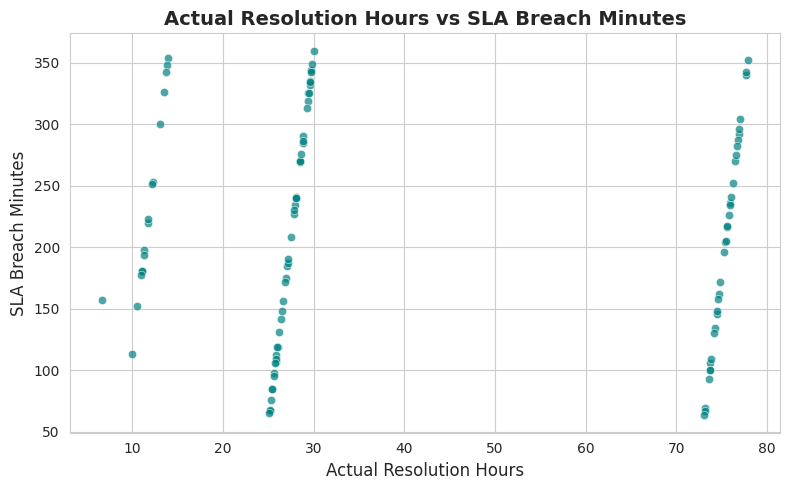

In [50]:
# Scatter Plot: Actual Resolution Hours vs SLA Breach Minutes

# Set figure size
plt.figure(figsize=(8, 5))

# Create scatter plot
sns.scatterplot(
    data=final_df,
    x='actual_hours',
    y='breach_minutes',
    color='teal',
    alpha=0.7
)

# Add chart title and axis labels
plt.title('Actual Resolution Hours vs SLA Breach Minutes',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Actual Resolution Hours', fontsize=12)
plt.ylabel('SLA Breach Minutes', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the chart
plt.show()

**Interpretation**


1.  The chart shows the relationship between actual resolution hours and SLA breach minutes for IT support tickets.
2.  The actual resolution hours range from 6.63 to 77.88 hours, while the SLA breach minutes range from 64 to 359 minutes. Tickets with longer resolution hours generally tend to have higher SLA breach minutes, indicating that delays in resolving tickets are associated with increased SLA breaches.











1.  **Columns**: actual_hours, breach_minutes
2.  **Business story** : The analysis indicates that tickets requiring longer resolution times are more likely to experience higher SLA breach durations. This highlights the importance of resolving tickets promptly to improve SLA compliance. Reducing resolution time, particularly for tickets with higher breach minutes, can enhance operational efficiency, improve service quality, and increase customer satisfaction.







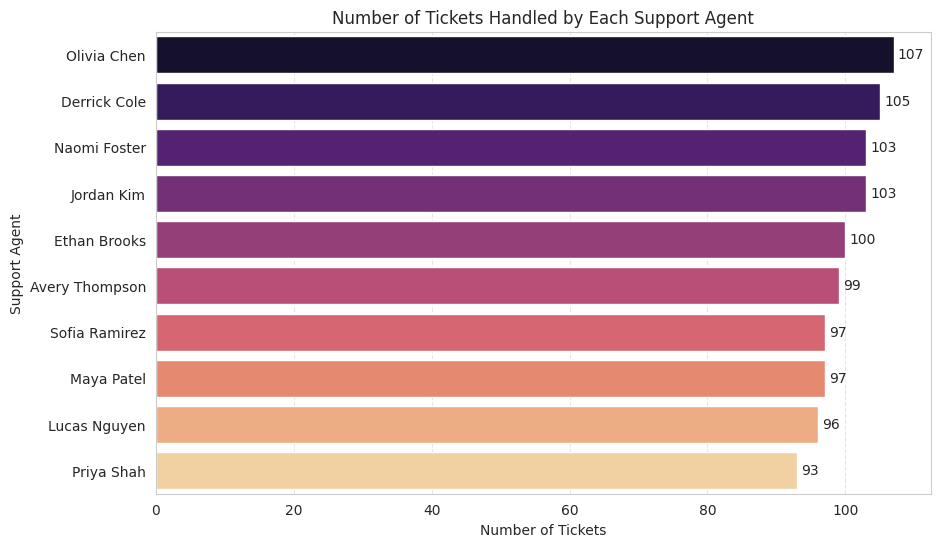

In [51]:
# Horizontal Bar Chart: Support Agent vs Number of Tickets
plt.figure(figsize=(10,6))

agent_counts = final_df['name_agent'].value_counts().reset_index()
agent_counts.columns = ['Support Agent', 'Number of Tickets']

ax = sns.barplot(
    data=agent_counts,
    y='Support Agent',
    x='Number of Tickets',
    hue='Support Agent',
    palette='magma',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Number of Tickets Handled by Each Support Agent')
plt.xlabel('Number of Tickets')
plt.ylabel('Support Agent')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

**Interpretation**


1.   The horizontal bar chart compares the number of tickets handled by each IT support agent, helping evaluate workload distribution among agents.
2.   The workload is fairly balanced across all support agents, with ticket counts ranging from 93 to 107. Olivia Chen handled the highest number of tickets (107), while Priya Shah handled the fewest (93).





1.   **Features Used**: name_agent and ticket_id (count of tickets)
2.  **Business story** : The balanced distribution of tickets among support agents indicates an efficient workload allocation process, supporting consistent team performance and effective resource utilization.







**Multivariate** **Analysis**


It examines the relationship among three or more variables to uncover deeper business insights. The following analyses are performed:


1. **Correlation Heatmap** – Identifies the relationship among numerical variables.
2. **Pivot Table Heatmap** – Compares average resolution hours across affected services and ticket priorities.


1.  **Grouped Bar Chart** – Compares ticket counts across support teams and priority levels.










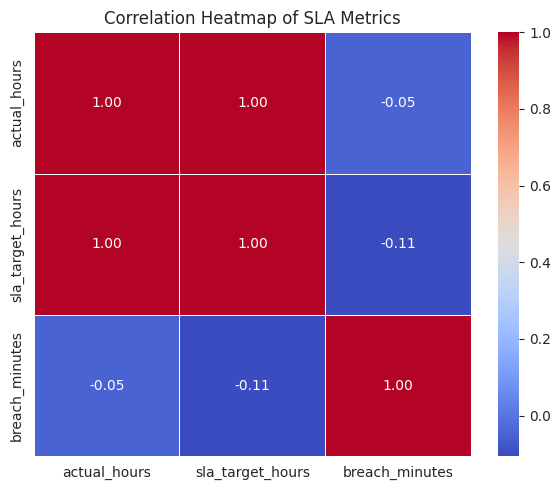

In [52]:
# Correlation Heatmap: Shows the relationship among Actual Resolution Hours,
# SLA Target Hours, and SLA Breach Minutes


# Select numerical columns
corr_data = final_df[['actual_hours',
                      'sla_target_hours',
                      'breach_minutes']]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of SLA Metrics')
plt.tight_layout()

plt.show()

**Interpretation**


1.   The Correlation Heatmap shows the relationship among Actual Resolution Hours, SLA Target Hours, and SLA Breach Minutes using correlation values ranging from -1 to +1.
2.   Actual Resolution Hours and SLA Target Hours have a very strong positive correlation (1.00), indicating they increase together.


1.   Breach Minutes has a very weak negative correlation with both Actual Resolution Hours (-0.05) and SLA Target Hours (-0.11), indicating almost no linear relationship.


1.   **Features Used**: sla_target_hours, actual_hours and  breach_minutes
2.   **Business story:** The heatmap indicates that resolution hours closely align with SLA targets, while SLA breach duration is influenced by factors beyond resolution time, such as ticket priority, escalation, or operational processes. This helps IT teams focus on improving overall SLA management rather than relying only on resolution time.








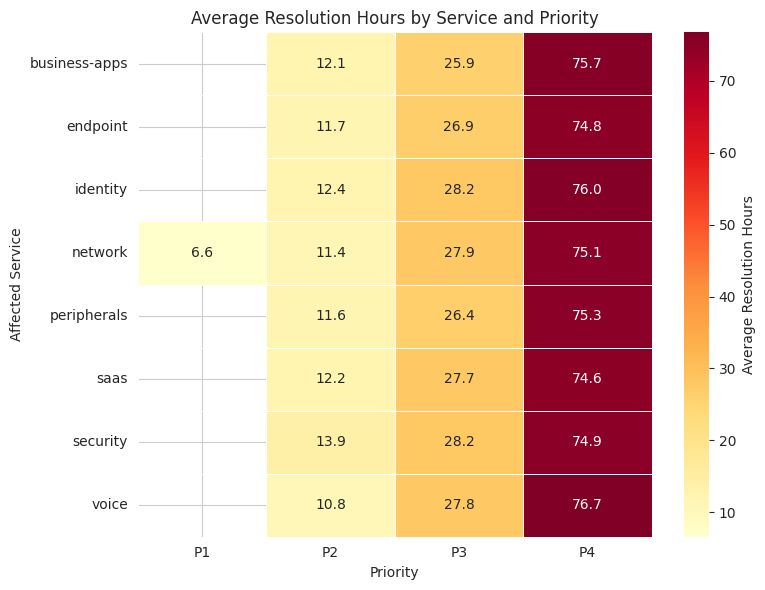

In [53]:
# Pivot table Heatmap: Average Resolution Hours by Service and Priority

# Create pivot table
pivot_data = final_df.pivot_table(
    values='actual_hours',
    index='affected_service',
    columns='priority',
    aggfunc='mean',
    observed=False
)

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Average Resolution Hours'}
)

plt.title('Average Resolution Hours by Service and Priority')
plt.xlabel('Priority')
plt.ylabel('Affected Service')

plt.tight_layout()
plt.show()

**Interpretation**


1.   The Pivot Table Heatmap shows the average resolution hours for different affected services across each ticket priority (P1–P4).
2.   P4 tickets have the highest average resolution hours across all services.


1.   Voice (76.7 hrs) and Identity (76.0 hrs) require the longest resolution time for P4 tickets.
2.  Network is the only service with recorded P1 tickets.


1.  **Features Used**: affected_service, priority, and actual_hours
2.   **Business story** : The analysis shows that actual resolution hours closely follow the SLA targets assigned to each priority level. High-priority (P1) tickets are resolved much faster, while low-priority (P4) tickets have longer resolution times due to their extended SLA limits, indicating that the IT team prioritizes critical issues first.








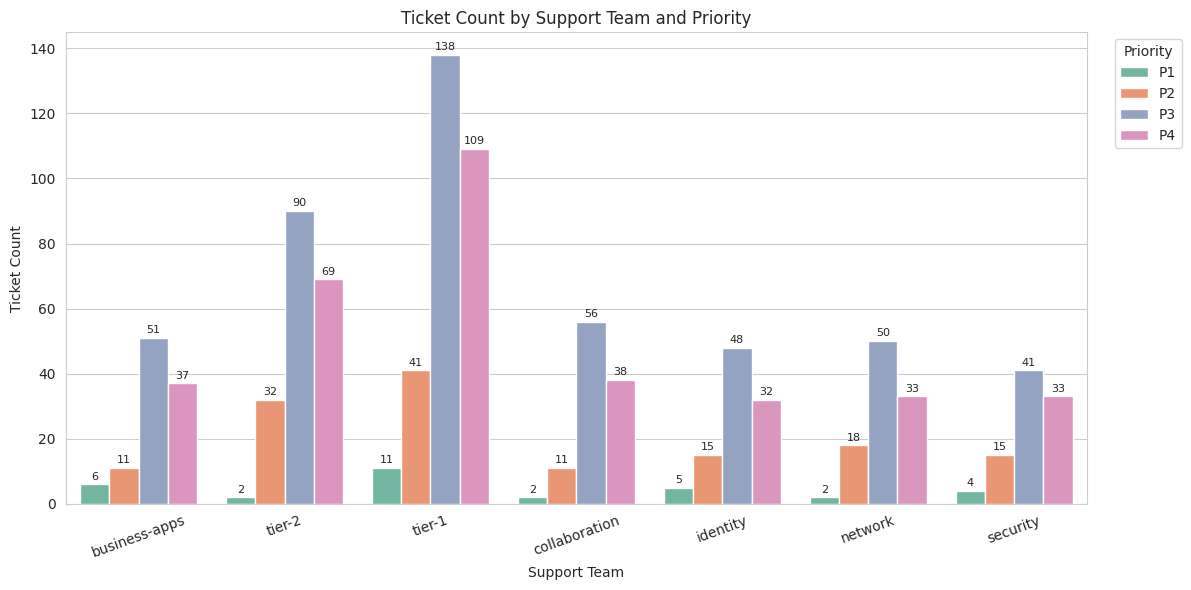

In [54]:
# Grouped Bar Chart: Ticket Count by Team and Priority

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=final_df,
    x='team',
    hue='priority',
    palette='Set2'
)

# Add labels on each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

plt.title('Ticket Count by Support Team and Priority')
plt.xlabel('Support Team')
plt.ylabel('Ticket Count')

# Move legend outside
plt.legend(title='Priority', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation**


1.  The grouped bar chart shows the number of tickets handled by each support team across different priority levels (P1–P4).
2. Tier-1 handled the highest number of tickets across all priority levels, especially P3 (138) and P4 (109).


1.  Tier-2 recorded the second-highest ticket volume, while other teams handled comparatively fewer tickets.
2. P3 and P4 tickets were more frequent than P1 and P2 across all support teams.


1.   **Features Used**: team, priority, and ticket_id (ticket count)
2.   **Business Story**: The chart highlights workload distribution across support teams and priority levels, helping IT management identify high-demand teams, allocate resources effectively, and improve service desk performance.








**Stage 4**

**Key Insights**


1.   **January (447)**  recorded the highest number of support tickets.



1.   **P3 (474) and P4 (351)** received the highest number of support tickets.
2.  **794** tickets were resolved, **105** were closed, **56** were in progress, and **45** were pending, indicating that **899** tickets were completed, while **101** tickets remained unresolved.


1.  **Laptop/Endpoint (138)** was the most common ticket category,**Endpoint (136)** was the most affected service, and **Email (371)** was the most used support channel.


1.   **Tier-1** handled the highest workload, with **138 P3** tickets and **109 P4** tickets.





1.  **101 SLA breaches**, **116 escalated tickets**, and no outage-related tickets were recorded.
2. Reducing SLA breaches, minimizing escalated tickets, and balancing team workload can improve overall IT service desk performance.







## Types of Analysis

| **Type of Analysis** | **Description** |
|----------------------|-----------------|
| **Descriptive Analysis** | Summarized ticket distribution and monthly trends using charts and summary statistics. |
| **Diagnostic Analysis** | Identified patterns in ticket priority, agent workload, SLA breaches, and escalations. |
| **Predictive Analysis** | Estimated future support demand based on monthly ticket trends. |
| **Prescriptive Analysis** | Suggested actions to improve SLA compliance and workload distribution. |
| **Recommendations / Decision Support** | Provided data-driven recommendations to improve IT service desk performance. |

**Future Enhancements**


1.   Include additional months  or more recent data for deeper trend analysis.
2.   Automate data analysis and reporting using Python scripts or interactive dashboards.


1.   Extend the project with predictive modeling to forecast ticket volumes or SLA breaches if needed.



